<a href="https://colab.research.google.com/github/adrianestebanrodriguez/Repositorio_Datasets/blob/main/calidad_aceite_de_oliva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

# Configuración estética
plt.style.use('ggplot')

In [ ]:
# Definición de tiempo (semanas)
semanas = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20,22,24,26,28,30,32,34,36,38,40,42,44,46,48])

# Simulación de Índice de Peróxidos (meq O2/kg)
# El límite legal para Virgen Extra suele ser 20
ip_20c = 2 + 0.3 * semanas + np.random.normal(0, 0.2, len(semanas))
ip_40c = 2 + 0.9 * semanas + np.random.normal(0, 0.3, len(semanas))
ip_60c = 2 + 2.5 * semanas + np.random.normal(0, 0.5, len(semanas))

df = pd.DataFrame({
    'Semana': semanas,
    'IP_20C': ip_20c,
    'IP_40C': ip_40c,
    'IP_60C': ip_60c
})

print("Primeras filas del dataset simulado:")
print(df.head())

Primeras filas del dataset simulado:
   Semana    IP_20C    IP_40C     IP_60C
0       0  2.214025  2.081002   2.186541
1       2  2.561468  3.578525   7.087749
2       4  3.102919  5.120963  11.036317
3       6  3.695710  7.038646  16.380257
4       8  3.926458  9.066254  22.337125


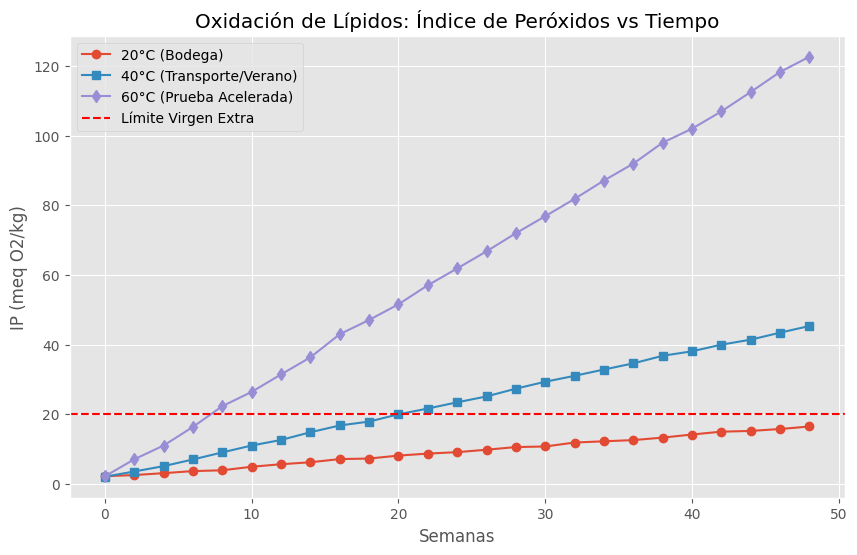

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df['Semana'], df['IP_20C'], 'o-', label='20°C (Bodega)')
plt.plot(df['Semana'], df['IP_40C'], 's-', label='40°C (Transporte/Verano)')
plt.plot(df['Semana'], df['IP_60C'], 'd-', label='60°C (Prueba Acelerada)')
plt.axhline(y=20, color='red', linestyle='--', label='Límite Virgen Extra')

plt.title('Oxidación de Lípidos: Índice de Peróxidos vs Tiempo')
plt.xlabel('Semanas')
plt.ylabel('IP (meq O2/kg)')
plt.legend()
plt.show()

In [ ]:
# Temperaturas en Kelvin
T_celsius = np.array([20, 40, 60])
T_kelvin = T_celsius + 273.15
inv_T = 1 / T_kelvin

# Calculamos las pendientes (k) para cada temperatura mediante regresión lineal simple
k_values = []
for col in ['IP_20C', 'IP_40C', 'IP_60C']:
    model = LinearRegression().fit(df[['Semana']], df[col])
    k_values.append(model.coef_[0])

# Relación de Arrhenius: ln(k) = ln(A) - Ea/R * (1/T)
ln_k = np.log(k_values)
R = 8.314 / 1000  # Constante de gases en kJ/(mol·K)

# Regresión para hallar Ea
arrhenius_model = LinearRegression().fit(inv_T.reshape(-1, 1), ln_k)
pendiente = arrhenius_model.coef_[0]
Ea = -pendiente * R

print(f"Energía de Activación calculada: {Ea:.2f} kJ/mol")

Energía de Activación calculada: 42.97 kJ/mol


In [ ]:
def predecir_vida_util(temp_ambiente_c):
    T_k = temp_ambiente_c + 273.15
    # Usamos el modelo de Arrhenius para predecir ln(k)
    ln_k_pred = arrhenius_model.predict([[1/T_k]])
    k_pred = np.exp(ln_k_pred)

    # Tiempo para llegar al límite de 20 meq O2/kg (partiendo de 2)
    semanas_vida = (20 - 2) / k_pred
    return semanas_vida[0]

# Ejemplo
t_prueba = 25
vida = predecir_vida_util(t_prueba)
print(f"A una temperatura constante de {t_prueba}°C, el aceite dejará de ser Virgen Extra en {vida:.1f} semanas.")

A una temperatura constante de 25°C, el aceite dejará de ser Virgen Extra en 44.6 semanas.


### Validación del modelo de Arrhenius

--- Validación del modelo de Arrhenius ---

Valores de k originales (obtenidos de la regresión lineal de los datos simulados):
  20°C: 0.3030
  40°C: 0.9084
  60°C: 2.5194

Valores de k predichos por el modelo de Arrhenius:
  20°C: 0.3003
  40°C: 0.9259
  60°C: 2.4940


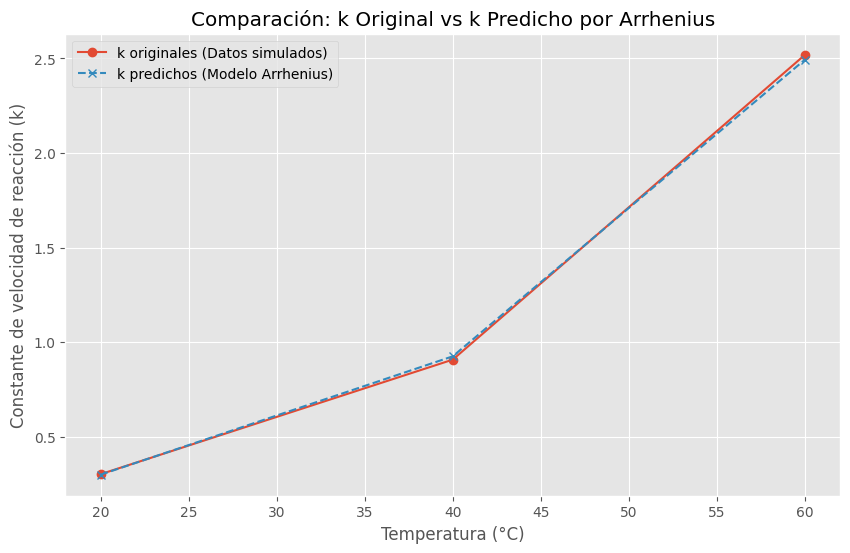


Errores porcentuales en k (predicho vs original):
  20°C: -0.89%
  40°C: 1.93%
  60°C: -1.01%


In [ ]:
print('--- Validación del modelo de Arrhenius ---')

# Temperaturas experimentales en Kelvin para predicción
T_kelvin_exp = T_celsius + 273.15

# Predecir ln(k) para cada temperatura experimental usando el modelo de Arrhenius
ln_k_pred_arrhenius = arrhenius_model.predict( (1 / T_kelvin_exp).reshape(-1, 1) )

# Convertir ln(k) predicho a k
k_pred_arrhenius = np.exp(ln_k_pred_arrhenius)

print('\nValores de k originales (obtenidos de la regresión lineal de los datos simulados):')
for i, k_orig in enumerate(k_values):
    print(f'  {T_celsius[i]}°C: {k_orig:.4f}')

print('\nValores de k predichos por el modelo de Arrhenius:')
for i, k_pred in enumerate(k_pred_arrhenius):
    print(f'  {T_celsius[i]}°C: {k_pred:.4f}')

# Visualización de la comparación
plt.figure(figsize=(10, 6))
plt.plot(T_celsius, k_values, 'o-', label='k originales (Datos simulados)')
plt.plot(T_celsius, k_pred_arrhenius, 'x--', label='k predichos (Modelo Arrhenius)')
plt.title('Comparación: k Original vs k Predicho por Arrhenius')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Constante de velocidad de reacción (k)')
plt.legend()
plt.grid(True)
plt.show()

# Calcular y mostrar errores
errores_k = (k_pred_arrhenius - k_values) / k_values * 100
print('\nErrores porcentuales en k (predicho vs original):')
for i, error in enumerate(errores_k):
    print(f'  {T_celsius[i]}°C: {error:.2f}%')


### Predicción de Vida Útil para un Rango de Temperaturas

In [ ]:
# Definir el rango de temperaturas ambiente
temperaturas_ambiente = np.arange(10, 71, 5) # De 10°C a 70°C en pasos de 5°C

# Calcular la vida útil para cada temperatura
vidas_utiles = [predecir_vida_util(temp) for temp in temperaturas_ambiente]

# Crear un DataFrame para mostrar los resultados
df_vida_util = pd.DataFrame({
    'Temperatura (°C)': temperaturas_ambiente,
    'Vida Útil (Semanas)': vidas_utiles
})

print("Vida útil predicha para diferentes temperaturas ambiente:")
display(df_vida_util)


Vida útil predicha para diferentes temperaturas ambiente:


,Temperatura (°C),Vida Útil (Semanas)
0,10,111.718213
1,15,81.389782
2,20,59.938803
3,25,44.596672
4,30,33.506769
5,35,25.409270
6,40,19.439645
7,45,14.998233
8,50,11.664814
9,55,9.142019


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_vida_util)

https://docs.google.com/spreadsheets/d/1oJNeXZKfVkgc1DA9bbbnLf9aLxj2rHMz6ThjEG1YhNY/edit#gid=0


### Resumen Estadístico de la Vida Útil según la Temperatura

In [ ]:
print("Resumen Estadístico de la Vida Útil (Semanas) por Temperatura:")
display(df_vida_util.describe())

Resumen Estadístico de la Vida Útil (Semanas) por Temperatura:


,Temperatura (°C),Vida Útil (Semanas)
count,13.000000,13.000000
mean,40.000000,33.027082
std,19.472202,33.170601
min,10.000000,4.592408
25%,25.000000,9.142019
50%,40.000000,19.439645
75%,55.000000,44.596672
max,70.000000,111.718213


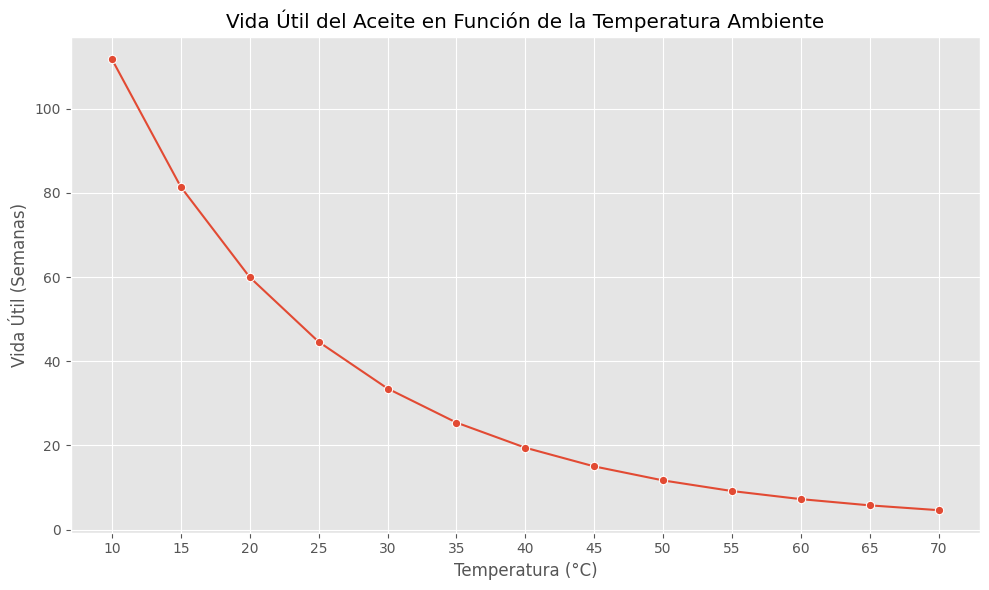

In [ ]:
# Visualizar la relación entre temperatura y vida útil
plt.figure(figsize=(10, 6))
sns.lineplot(x='Temperatura (°C)', y='Vida Útil (Semanas)', data=df_vida_util, marker='o')
plt.title('Vida Útil del Aceite en Función de la Temperatura Ambiente')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Vida Útil (Semanas)')
plt.grid(True)
plt.xticks(temperaturas_ambiente) # Mostrar todas las temperaturas en el eje x
plt.tight_layout()
plt.show()